# 03 - Regresión

Predecir `popularity` a partir de las variables de audio. Se comparan regresión lineal,
polinomial con Ridge y gradient boosting, usando MSE de train/test.

In [1]:
from pathlib import Path
import warnings

from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore", category=PendingDeprecationWarning, module="seaborn")

SPOTIFY_GREEN = "#1DB954"
SPOTIFY_BLACK = "#191414"
SPOTIFY_GRAY = "#535353"
SPOTIFY_PALETTE = ["#1DB954", "#1ED760", "#0E7A37", "#73E68C", "#117A37", "#0A5C29"]
SPOTIFY_SEQ = LinearSegmentedColormap.from_list("spotify_seq", ["#FFFFFF", "#1DB954", "#0A4A22"])
SPOTIFY_DIVERGE = LinearSegmentedColormap.from_list("spotify_div", ["#191414", "#FFFFFF", "#1DB954"])


def apply_spotify_theme():
    import matplotlib as mpl
    import seaborn as sns

    sns.set_theme(style="whitegrid", palette=SPOTIFY_PALETTE)
    mpl.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titleweight": "bold",
        "axes.titlecolor": SPOTIFY_BLACK,
        "axes.labelcolor": SPOTIFY_BLACK,
        "axes.edgecolor": "#C9C9C9",
        "grid.color": "#ECECEC",
        "text.color": SPOTIFY_BLACK,
        "font.size": 11,
        "axes.titlesize": 14,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    })


PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
DATA_CLEAN = PROJECT_ROOT / "data" / "processed" / "spotify_tracks_clean.csv"

RANDOM_STATE = 42

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

apply_spotify_theme()
df = pd.read_csv(DATA_CLEAN)
print(df.shape)
display(df.head())

(89741, 23)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,is_explicit,popularity_class
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433,0,High
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500,0,High
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767,0,High
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550,0,High
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217,0,High


## Variables

Se excluyen identificadores y texto; `track_genre` entra con one-hot.

In [3]:
target = "popularity"
numeric_features = [
    "duration_min", "is_explicit", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature"
]
categorical_features = ["track_genre"]

X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(71792, 15) (17949, 15)


In [4]:
encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)

linear_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("genre", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder)
        ]), categorical_features)
    ]
)

linear_model = Pipeline([
    ("preprocess", linear_preprocess),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

linear_train_mse = mean_squared_error(y_train, linear_train_pred)
linear_test_mse = mean_squared_error(y_test, linear_test_pred)
print(f"MSE train (lineal): {linear_train_mse:.3f}")
print(f"MSE test (lineal): {linear_test_mse:.3f}")

MSE train (lineal): 283.706
MSE test (lineal): 283.750


## Regresión polinomial

Grados 2 y 3 con Ridge para controlar el sobreajuste. El polinomio solo se aplica
a las numéricas; el género se queda lineal.

In [5]:
def make_encoder(drop_first=True):
    return OneHotEncoder(
        handle_unknown="ignore",
        drop="first" if drop_first else None,
        sparse_output=False,
    )


polynomial_results = []
polynomial_models = {}

for degree in [2, 3]:
    for alpha in [0.1, 1.0, 10.0, 100.0]:
        polynomial_preprocess = ColumnTransformer(
            transformers=[
                ("num_poly", Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
                ]), numeric_features),
                ("genre", Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_encoder(drop_first=True)),
                ]), categorical_features),
            ]
        )

        model_name = f"Ridge polinomial grado {degree}, alpha {alpha:g}"
        candidate = Pipeline([
            ("preprocess", polynomial_preprocess),
            ("model", Ridge(alpha=alpha)),
        ])
        candidate.fit(X_train, y_train)
        train_pred = candidate.predict(X_train)
        test_pred = candidate.predict(X_test)
        train_mse = mean_squared_error(y_train, train_pred)
        test_mse = mean_squared_error(y_test, test_pred)
        polynomial_results.append({
            "model": model_name,
            "degree": degree,
            "alpha": alpha,
            "train_mse": train_mse,
            "test_mse": test_mse,
            "test_rmse": np.sqrt(test_mse),
            "gap": test_mse - train_mse,
        })
        polynomial_models[model_name] = candidate

polynomial_results_df = (
    pd.DataFrame(polynomial_results)
    .sort_values("test_mse")
    .reset_index(drop=True)
)
display(polynomial_results_df.round(3))

best_polynomial_row = polynomial_results_df.iloc[0]
best_polynomial_model = polynomial_models[best_polynomial_row["model"]]
poly_train_pred = best_polynomial_model.predict(X_train)
poly_test_pred = best_polynomial_model.predict(X_test)
poly_train_mse = best_polynomial_row["train_mse"]
poly_test_mse = best_polynomial_row["test_mse"]
print(f"Mejor polinomial: {best_polynomial_row['model']}")
print(f"MSE train: {poly_train_mse:.3f}")
print(f"MSE test: {poly_test_mse:.3f}")

,model,degree,alpha,train_mse,test_mse,test_rmse,gap
0,"Ridge polinomial grado 3, alpha 0.1",3,0.1,275.662,281.250,16.771,5.588
1,"Ridge polinomial grado 3, alpha 1",3,1.0,275.674,281.305,16.772,5.631
2,"Ridge polinomial grado 3, alpha 10",3,10.0,275.957,281.738,16.785,5.781
3,"Ridge polinomial grado 2, alpha 0.1",2,0.1,280.421,281.760,16.786,1.338
4,"Ridge polinomial grado 2, alpha 1",2,1.0,280.433,281.814,16.787,1.381
5,"Ridge polinomial grado 2, alpha 10",2,10.0,280.709,282.225,16.800,1.516
6,"Ridge polinomial grado 3, alpha 100",3,100.0,278.936,284.603,16.870,5.667
7,"Ridge polinomial grado 2, alpha 100",2,100.0,283.657,284.888,16.879,1.231


Mejor polinomial: Ridge polinomial grado 3, alpha 0.1
MSE train: 275.662
MSE test: 281.250


## Gradient boosting

In [6]:
boosting_results = []
boosting_models = {}

for learning_rate in [0.04, 0.06, 0.08]:
    boosting_preprocess = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_features),
            ("genre", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_encoder(drop_first=False)),
            ]), categorical_features),
        ]
    )
    model_name = f"HistGradientBoosting lr {learning_rate}"
    candidate = Pipeline([
        ("preprocess", boosting_preprocess),
        ("model", HistGradientBoostingRegressor(
            max_iter=250,
            learning_rate=learning_rate,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=RANDOM_STATE,
        )),
    ])
    candidate.fit(X_train, y_train)
    train_pred = candidate.predict(X_train)
    test_pred = candidate.predict(X_test)
    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    boosting_results.append({
        "model": model_name,
        "learning_rate": learning_rate,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "test_rmse": np.sqrt(test_mse),
        "gap": test_mse - train_mse,
    })
    boosting_models[model_name] = candidate

boosting_results_df = (
    pd.DataFrame(boosting_results)
    .sort_values("test_mse")
    .reset_index(drop=True)
)
display(boosting_results_df.round(3))

best_boosting_row = boosting_results_df.iloc[0]
best_boosting_model = boosting_models[best_boosting_row["model"]]
boosting_train_pred = best_boosting_model.predict(X_train)
boosting_test_pred = best_boosting_model.predict(X_test)
boosting_train_mse = best_boosting_row["train_mse"]
boosting_test_mse = best_boosting_row["test_mse"]
print(f"Mejor boosting: {best_boosting_row['model']}")
print(f"MSE train: {boosting_train_mse:.3f}")
print(f"MSE test: {boosting_test_mse:.3f}")

,model,learning_rate,train_mse,test_mse,test_rmse,gap
0,HistGradientBoosting lr 0.08,0.08,226.335,251.406,15.856,25.071
1,HistGradientBoosting lr 0.06,0.06,234.778,254.810,15.963,20.032
2,HistGradientBoosting lr 0.04,0.04,246.477,260.114,16.128,13.638


Mejor boosting: HistGradientBoosting lr 0.08
MSE train: 226.335
MSE test: 251.406


In [7]:
mse_table = pd.DataFrame([
    {
        "model": "Regresión lineal (baseline)",
        "train_mse": linear_train_mse,
        "test_mse": linear_test_mse,
        "test_rmse": np.sqrt(linear_test_mse),
        "gap": linear_test_mse - linear_train_mse,
    },
    best_polynomial_row[["model", "train_mse", "test_mse", "test_rmse", "gap"]].to_dict(),
    best_boosting_row[["model", "train_mse", "test_mse", "test_rmse", "gap"]].to_dict(),
])
mse_table["mejora_vs_baseline_pct"] = 100 * (linear_test_mse - mse_table["test_mse"]) / linear_test_mse
mse_table = mse_table.sort_values("test_mse").reset_index(drop=True)
display(mse_table.round(3))

,model,train_mse,test_mse,test_rmse,gap,mejora_vs_baseline_pct
0,HistGradientBoosting lr 0.08,226.335,251.406,15.856,25.071,11.399
1,"Ridge polinomial grado 3, alpha 0.1",275.662,281.250,16.771,5.588,0.881
2,Regresión lineal (baseline),283.706,283.750,16.845,0.044,0.000


## Coeficientes del modelo lineal

In [8]:
preprocessor = linear_model.named_steps["preprocess"]
feature_names = preprocessor.get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

coef_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coefficient=lambda x: x["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)
display(coef_table.head(20))

,feature,coefficient,abs_coefficient
72,genre__track_genre_iranian,-38.737928,38.737928
106,genre__track_genre_romance,-37.450894,37.450894
80,genre__track_genre_latin,-32.461991,32.461991
77,genre__track_genre_jazz,-31.473212,31.473212
37,genre__track_genre_detroit-techno,-31.189584,31.189584
26,genre__track_genre_chicago-house,-30.217325,30.217325
79,genre__track_genre_kids,-27.233711,27.233711
29,genre__track_genre_classical,-26.706648,26.706648
55,genre__track_genre_grindcore,-26.222319,26.222319
67,genre__track_genre_idm,-25.859308,25.859308


## Real vs. predicho

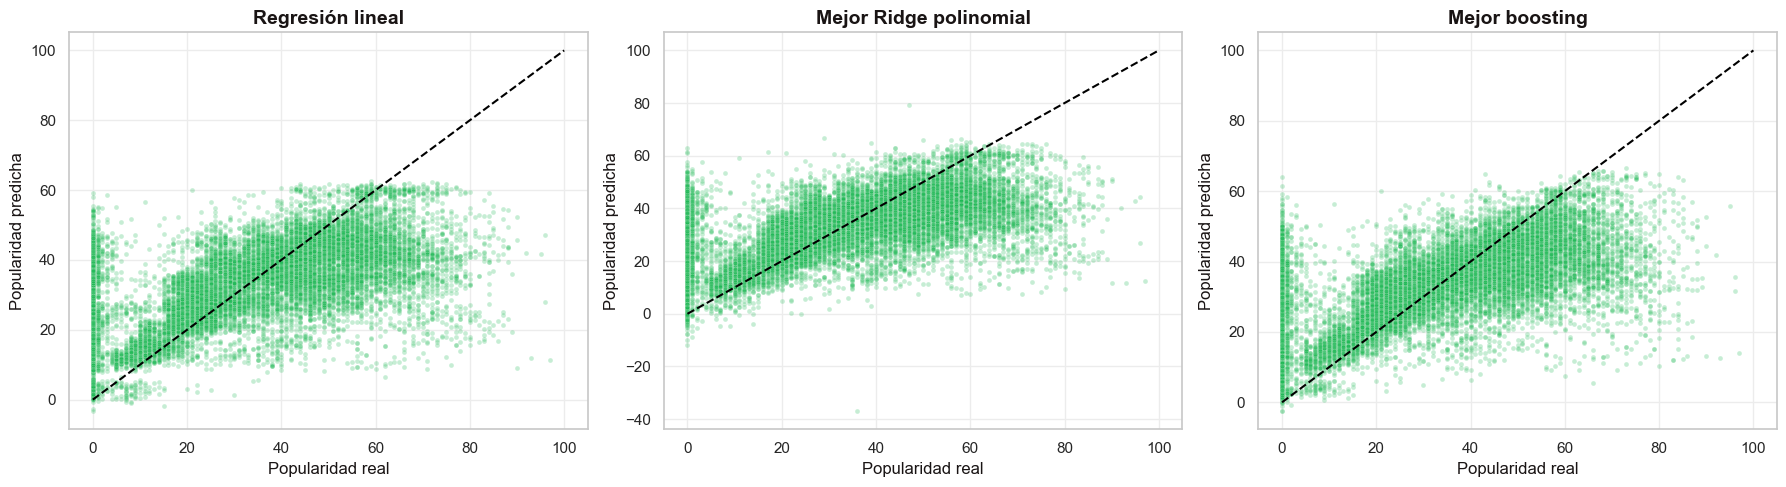

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_test, y=linear_test_pred, alpha=0.25, s=12, ax=axes[0])
axes[0].plot([0, 100], [0, 100], color="black", linestyle="--")
axes[0].set_title("Regresión lineal")
axes[0].set_xlabel("Popularidad real")
axes[0].set_ylabel("Popularidad predicha")

sns.scatterplot(x=y_test, y=poly_test_pred, alpha=0.25, s=12, ax=axes[1])
axes[1].plot([0, 100], [0, 100], color="black", linestyle="--")
axes[1].set_title("Mejor Ridge polinomial")
axes[1].set_xlabel("Popularidad real")
axes[1].set_ylabel("Popularidad predicha")

sns.scatterplot(x=y_test, y=boosting_test_pred, alpha=0.25, s=12, ax=axes[2])
axes[2].plot([0, 100], [0, 100], color="black", linestyle="--")
axes[2].set_title("Mejor boosting")
axes[2].set_xlabel("Popularidad real")
axes[2].set_ylabel("Popularidad predicha")

plt.tight_layout()
plt.show()

In [10]:
best_model = mse_table.iloc[0]
mejora_pct = 100 * (linear_test_mse - best_model["test_mse"]) / linear_test_mse
print(f"Mejor modelo: {best_model['model']}")
print(f"MSE test: {best_model['test_mse']:.2f} (RMSE ~{best_model['test_rmse']:.2f} puntos de popularidad)")
print(f"Mejora vs. baseline lineal: {mejora_pct:.1f}%")

Mejor modelo: HistGradientBoosting lr 0.08
MSE test: 251.41 (RMSE ~15.86 puntos de popularidad)
Mejora vs. baseline lineal: 11.4%
